1. Import Dataset

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
path = path + '/GlobalWeatherRepository.csv'
dataset0 = pd.read_csv(path)

dataset0['last_updated'] = pd.to_datetime(dataset0['last_updated'])

# Sort by Location and Time
dataset0 = dataset0.sort_values(['location_name', 'last_updated']).reset_index(drop=True)

dataset = dataset0.copy()
dataset1 = dataset.copy()
cols = dataset1.select_dtypes(include=['int', 'float']).columns.tolist()
dataset.head(3)

Using Colab cache for faster access to the 'global-weather-repository' dataset.


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717164900,2024-05-31 16:15:00,16.0,60.8,Moderate rain,...,2.2,3.4,1,1,05:36 AM,09:52 PM,02:59 AM,02:09 PM,Waning Crescent,47
1,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717252200,2024-06-01 16:30:00,16.0,60.8,Overcast,...,6.5,19.6,1,1,05:35 AM,09:53 PM,03:12 AM,03:34 PM,Waning Crescent,35
2,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717510500,2024-06-04 16:15:00,18.0,64.4,Partly cloudy,...,5.7,6.0,1,1,05:33 AM,09:56 PM,03:56 AM,07:57 PM,Waning Crescent,8


1. Advanced EDA: Implementation anomaly detection and outlier analysis.

Z-Score, IQR, & Modified Z-Score Outliers

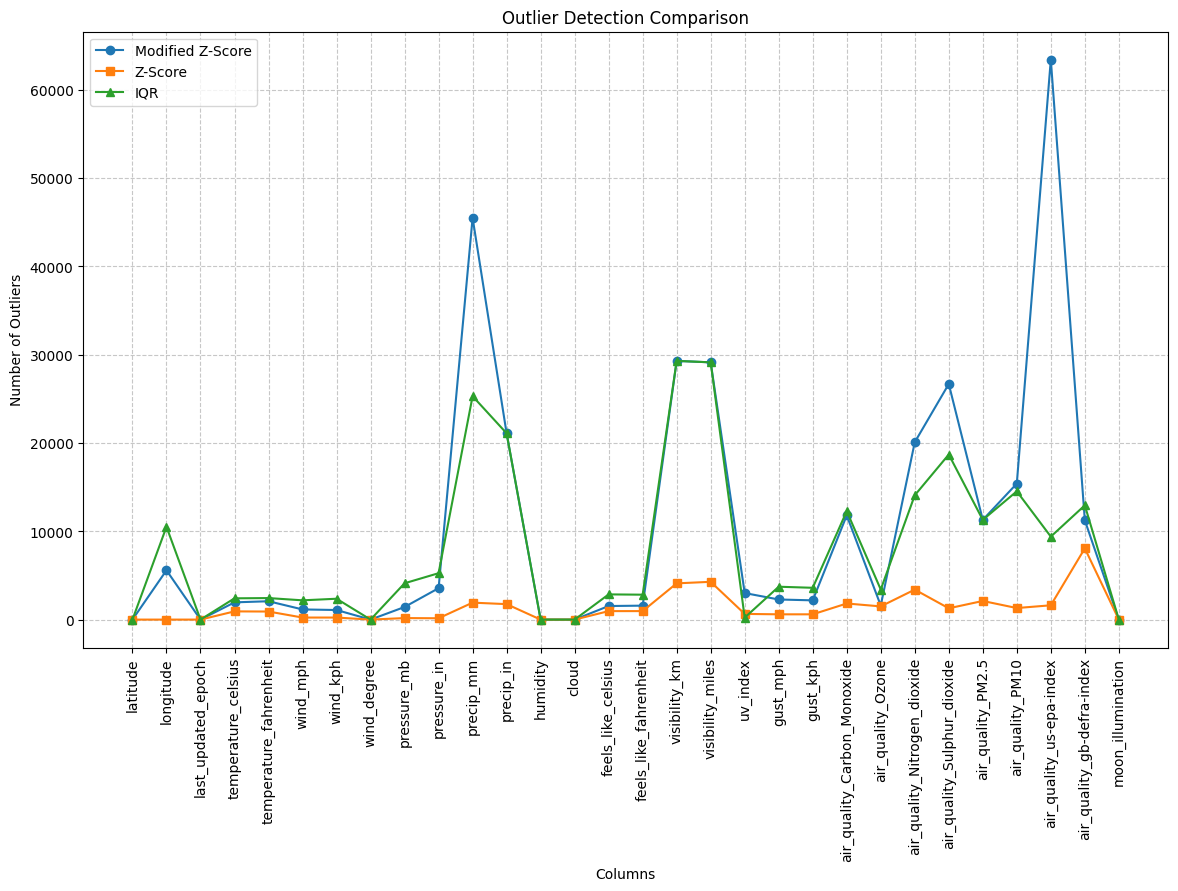

In [ ]:
from scipy import stats

# Z-Score
z_scores = dataset1[cols].apply(stats.zscore)
outliers_z = (z_scores.abs() > 3)

# IQR
def flag_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

# Modified Z-Score
def modified_zscore(series):
    median = series.median()
    mad = (series - median).abs().median()
    return 0.6745 * (series - median) / mad

for col in cols:
  dataset1[f'mz_outlier_{col}'] = modified_zscore(dataset1[col]).abs() > 3.5
  dataset1[f'iqr_outlier_{col}'] = flag_iqr_outliers(dataset1[col])


n1 = np.array(dataset1[[f'mz_outlier_{c}' for c in cols]].sum())
n2 = np.array(outliers_z.sum())
n3 = np.array(dataset1[[f'iqr_outlier_{c}' for c in cols]].sum())

plt.figure(figsize=(14, 8))
plt.plot(cols, n1, label='Modified Z-Score', marker='o')
plt.plot(cols, n2, label='Z-Score', marker='s')
plt.plot(cols, n3, label='IQR', marker='^')
plt.xlabel('Columns')
plt.ylabel('Number of Outliers')
plt.title('Outlier Detection Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
print()

Isolation Forest Anomalies, LOF Anomalies, & DBSCAN Outliers

Isolation Forest anomalies: 1293
LOF anomalies: 6832
DBSCAN outliers: 56539


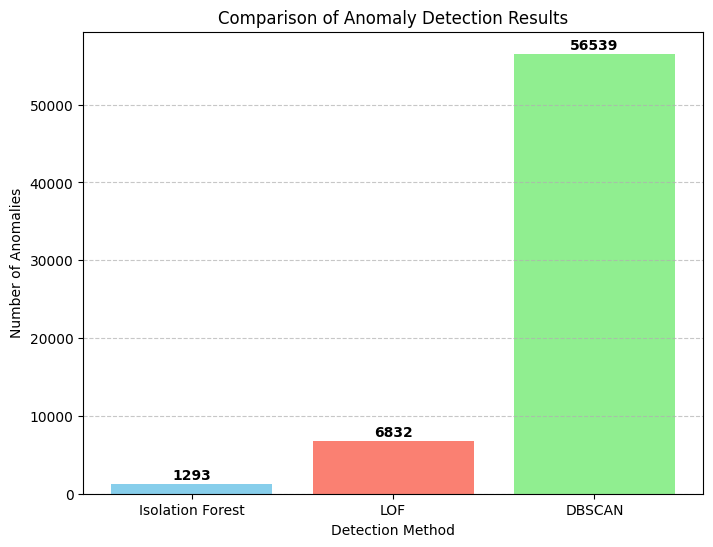

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

X = dataset1[cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=1, contamination=0.05, random_state=42)
dataset1.loc[X.index, 'iso_forest_label'] = iso.fit_predict(X_scaled)
dataset1.loc[X.index, 'iso_forest_score'] = iso.score_samples(X_scaled)

# -1 = anomaly, 1 = normal
print("Isolation Forest anomalies:", (dataset1['iso_forest_label'] == -1).sum())

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
dataset1.loc[X.index, 'lof_label'] = lof.fit_predict(X_scaled)
dataset1.loc[X.index, 'lof_score'] = lof.negative_outlier_factor_

print("LOF anomalies:", (dataset1['lof_label'] == -1).sum())

db = DBSCAN(eps=1.5, min_samples=10)
dataset1.loc[X.index, 'dbscan_label'] = db.fit_predict(X_scaled)

# -1 = outlier
print("DBSCAN outliers:", (dataset1['dbscan_label'] == -1).sum())

anomaly_counts = {
    'Isolation Forest': (dataset1['iso_forest_label'] == -1).sum(),
    'LOF': (dataset1['lof_label'] == -1).sum(),
    'DBSCAN': (dataset1['dbscan_label'] == -1).sum()
}

plt.figure(figsize=(8, 6))
plt.bar(anomaly_counts.keys(), anomaly_counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Detection Method')
plt.ylabel('Number of Anomalies')
plt.title('Comparison of Anomaly Detection Results')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(anomaly_counts.values()): plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

Physical Impossibility Checks


Total rows with at least one issue: 19%.


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'wind_kph_extreme'),
  Text(1, 0, 'wind_mph_extreme'),
  Text(2, 0, 'pressure_mb_out_of_range'),
  Text(3, 0, 'pressure_in_out_of_range'),
  Text(4, 0, 'visibility_km_mi_mismatch'),
  Text(5, 0, 'air_quality_Carbon_Monoxide_negative'),
  Text(6, 0, 'air_quality_Sulphur_dioxide_negative'),
  Text(7, 0, 'air_quality_PM10_negative'),
  Text(8, 0, 'pm25_greater_than_pm10'),
  Text(9, 0, 'max_humidity_no_rain'),
  Text(10, 0, 'clear_sky_with_rain'),
  Text(11, 0, 'high_uv_full_cloud')])

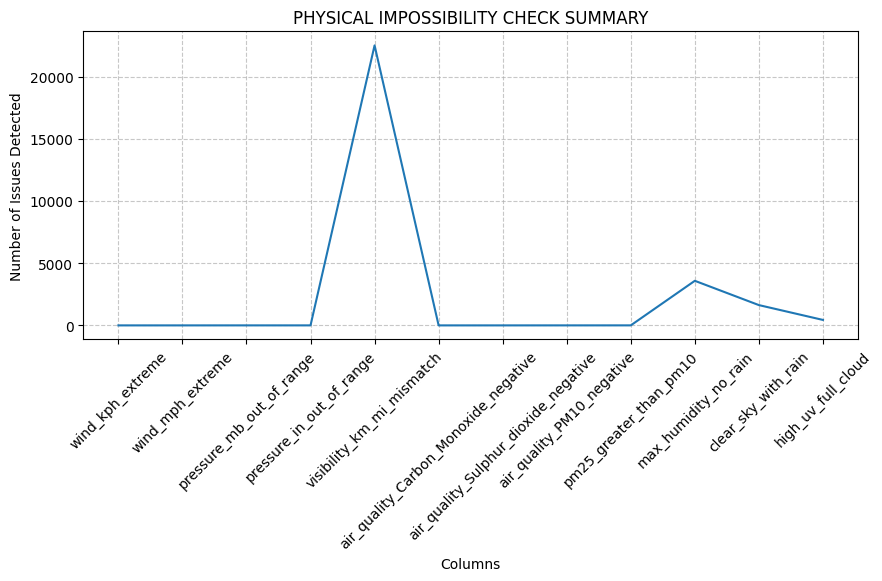

In [ ]:
issues = pd.DataFrame(index=dataset1.index)
# Temperature
issues['temp_c_out_of_range']   = ~dataset1['temperature_celsius'].between(-90, 57)
issues['temp_f_out_of_range']   = ~dataset1['temperature_fahrenheit'].between(-130, 135)

# Celsius and Fahrenheit must be consistent.
issues['temp_cf_mismatch'] = (dataset1['temperature_fahrenheit'] - (dataset1['temperature_celsius'] * 9/5 + 32)).abs() > 1.0

# Feels-like consistency
issues['feels_like_cf_mismatch'] = (dataset1['feels_like_fahrenheit'] - (dataset1['feels_like_celsius'] * 9/5 + 32)).abs() > 1.0

# Feels-like should be reasonably close to actual temp.
issues['feels_like_extreme_diff'] = (dataset1['feels_like_celsius'] - dataset1['temperature_celsius']).abs() > 30

# Humidity
issues['humidity_out_of_range']  = ~dataset1['humidity'].between(0, 100)

# Wind
issues['wind_kph_negative'] = dataset1['wind_kph'] < 0
issues['wind_kph_extreme'] = dataset1['wind_kph'] > 410
issues['wind_mph_negative'] = dataset1['wind_mph'] < 0
issues['wind_mph_extreme'] = dataset1['wind_mph'] > 255

# wind_mph and wind_kph must be consistent.
issues['wind_mph_kph_mismatch']  = (dataset1['wind_kph'] - (dataset1['wind_mph'] * 1.60934)).abs() > 1.0

# Gust should always be >= sustained wind speed
issues['gust_less_than_wind_kph'] = dataset1['gust_kph'] < dataset1['wind_kph']
issues['gust_less_than_wind_mph'] = dataset1['gust_mph'] < dataset1['wind_mph']

# Wind degree must lies within range.
issues['wind_degree_out_of_range'] = ~dataset1['wind_degree'].between(0, 360)

# Pressure
issues['pressure_mb_out_of_range'] = ~dataset1['pressure_mb'].between(870, 1084)
issues['pressure_in_out_of_range'] = ~dataset1['pressure_in'].between(25.69, 32.01)

# mb and inches must be consistent.
expected_in = dataset1['pressure_mb'] * 0.02953
issues['pressure_mb_in_mismatch']  = (dataset1['pressure_in'] - expected_in).abs() > 0.05

# Precipitation
issues['precip_mm_negative'] = dataset1['precip_mm'] < 0
issues['precip_in_negative'] = dataset1['precip_in'] < 0

issues['precip_mm_extreme']      = dataset1['precip_mm'] > 1825
issues['precip_in_extreme']      = dataset1['precip_in'] > 72

# mm and inches must be consistent.
issues['precip_mm_in_mismatch']  = (dataset1['precip_mm'] - (dataset1['precip_in'] * 25.4)).abs() > 0.5

# Visibility
issues['visibility_km_negative'] = dataset1['visibility_km'] < 0
issues['visibility_km_extreme'] = dataset1['visibility_km'] > 120
issues['visibility_miles_negative'] = dataset1['visibility_miles'] < 0

# km and miles must be consistent.
expected_vis_km = dataset1['visibility_miles'] * 1.60934
issues['visibility_km_mi_mismatch'] = (dataset1['visibility_km'] - expected_vis_km).abs() > 0.5

# Cloud Cover
issues['cloud_out_of_range'] = ~dataset1['cloud'].between(0, 100)

# UV Index
issues['uv_index_negative']      = dataset1['uv_index'] < 0
issues['uv_index_extreme']       = dataset1['uv_index'] > 20

# Air Quality
aq_cols = [
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10']
for col in aq_cols: issues[f'{col}_negative'] = dataset1[col] < 0

# PM2.5 should never exceed PM10.
issues['pm25_greater_than_pm10'] = dataset1['air_quality_PM2.5'] > dataset1['air_quality_PM10']

# EPA index: 1–6, DEFRA index: 1–10
issues['epa_index_out_of_range']   = ~dataset1['air_quality_us-epa-index'].between(1, 6)
issues['defra_index_out_of_range'] = ~dataset1['air_quality_gb-defra-index'].between(1, 10)

# Cross-variable Co-occurrence Checks
issues['max_humidity_no_rain']   = (dataset1['humidity'] == 100) & (dataset1['precip_mm'] == 0)

# Clear sky (cloud=0) should not have precipitation
issues['clear_sky_with_rain']    = (dataset1['cloud'] == 0) & (dataset1['precip_mm'] > 0)

# UV index > 5 should not occur with 100% cloud cover
issues['high_uv_full_cloud']     = (dataset1['uv_index'] > 5) & (dataset1['cloud'] == 100)

df_issues = pd.concat([dataset1, issues], axis=1)
summary = issues.sum().sort_values(ascending=False)
summary = summary[summary > 0]

print(f"\nTotal rows with at least one issue: {int(issues.any(axis=1).sum() * 100 / len(dataset1))}%.")

xxx = issues.sum()[issues.sum()>0]
plt.figure(figsize=(10, 4))
plt.plot(list(xxx.index), list(xxx))
plt.xlabel('Columns')
plt.ylabel('Number of Issues Detected')
plt.title("PHYSICAL IMPOSSIBILITY CHECK SUMMARY")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

Rolling Mean ± 3σ Outlier

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'rolling_outlier_temperature_celsius'),
  Text(1, 0, 'rolling_outlier_humidity'),
  Text(2, 0, 'rolling_outlier_wind_kph'),
  Text(3, 0, 'rolling_outlier_pressure_mb'),
  Text(4, 0, 'rolling_outlier_air_quality_PM2.5')])

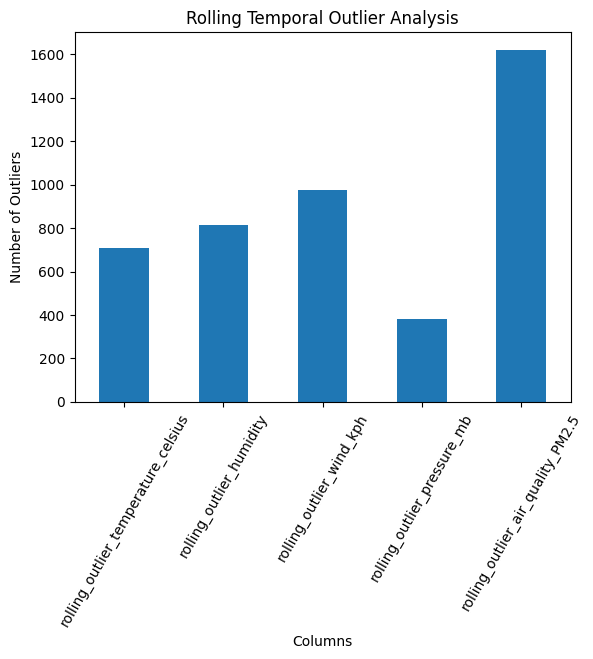

In [ ]:
dataset1['last_updated'] = pd.to_datetime(dataset1['last_updated'])
dataset1.sort_values(['location_name', 'last_updated'], inplace=True)

temporal_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb', 'air_quality_PM2.5']

for col in temporal_cols:
    grp = dataset1.groupby('location_name')[col]
    roll_mean = grp.transform(lambda x: x.rolling(24, min_periods=3).mean())
    roll_std = grp.transform(lambda x: x.rolling(24, min_periods=3).std())
    dataset1[f'rolling_outlier_{col}'] = ((dataset1[col] > roll_mean + 3 * roll_std) | (dataset1[col] < roll_mean - 3 * roll_std))


dataset1[[f'rolling_outlier_{c}' for c in temporal_cols]].sum().plot(kind='bar')
plt.xlabel('Columns')
plt.ylabel('Number of Outliers')
plt.title('Rolling Temporal Outlier Analysis')
plt.xticks(rotation=60)

Condition vs Numeric Mismatch

Top specific violations:

 condition_violation
Sunny: cloud=25 > 20            3754
Overcast: cloud=0 < 80           958
Clear: cloud=25 > 20             859
Overcast: cloud=75 < 80          572
Overcast: cloud=50 < 80          460
Overcast: cloud=25 < 80          426
Heavy rain: precip=0.0 < 7.6     329
Fog: vis=10.0 > 1.0              261
Sunny: cloud=21 > 20             197
Sunny: cloud=22 > 20             185
Name: count, dtype: int64


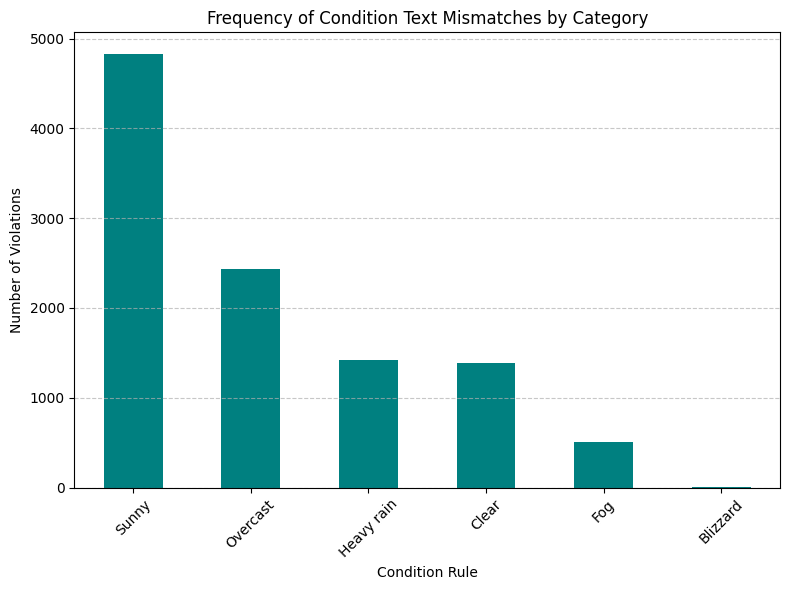

In [ ]:
condition_rules = { 'Sunny':        {'cloud_max': 20,  'precip_max': 0.0},
                    'Clear':        {'cloud_max': 20,  'precip_max': 0.0},
                    'Overcast':     {'cloud_min': 80},
                    'Blizzard':     {'temp_max':  2,   'wind_min':  56},
                    'Fog':          {'visibility_max': 1.0},
                    'Heavy rain':   {'precip_min': 7.6},
                    'Thunderstorm': {'precip_min': 0.1, 'cloud_min': 60},}

def check_condition(row):
    text = str(row['condition_text']).strip().lower()
    violations = []
    for cond, rules in condition_rules.items():
        if cond.lower() in text:
            if 'cloud_max' in rules and row['cloud'] > rules['cloud_max']:
                violations.append(f"{cond}: cloud={row['cloud']} > {rules['cloud_max']}")
            if 'cloud_min' in rules and row['cloud'] < rules['cloud_min']:
                violations.append(f"{cond}: cloud={row['cloud']} < {rules['cloud_min']}")
            if 'precip_max' in rules and row['precip_mm'] > rules['precip_max']:
                violations.append(f"{cond}: precip={row['precip_mm']} > {rules['precip_max']}")
            if 'precip_min' in rules and row['precip_mm'] < rules['precip_min']:
                violations.append(f"{cond}: precip={row['precip_mm']} < {rules['precip_min']}")
            if 'temp_max' in rules and row['temperature_celsius'] > rules['temp_max']:
                violations.append(f"{cond}: temp={row['temperature_celsius']} > {rules['temp_max']}")
            if 'wind_min' in rules and row['wind_kph'] < rules['wind_min']:
                violations.append(f"{cond}: wind={row['wind_kph']} < {rules['wind_min']}")
            if 'visibility_max' in rules and row['visibility_km'] > rules['visibility_max']:
                violations.append(f"{cond}: vis={row['visibility_km']} > {rules['visibility_max']}")
    return '; '.join(violations) if violations else None

dataset1['condition_violation'] = dataset1.apply(check_condition, axis=1)

all_violations = dataset1['condition_violation'].dropna().str.split('; ').explode()
violation_types = all_violations.str.split(':').str[0].value_counts()

plt.figure(figsize=(8, 6))
violation_types.plot(kind='bar', color='teal')
plt.title('Frequency of Condition Text Mismatches by Category')
plt.xlabel('Condition Rule')
plt.ylabel('Number of Violations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

print("Top specific violations:\n\n", all_violations.value_counts().head(10))

Forecasting Models

XGBoost

a) Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')


Y = dataset['temperature_celsius'].copy()

# Drop Irrelevant & Redundant Columns
dataset.drop(columns=['country', 'latitude', 'longitude', 'timezone',
                      'last_updated_epoch', 'last_updated', 'temperature_celsius',
                      'temperature_fahrenheit', 'feels_like_fahrenheit', 'feels_like_celsius', 'gust_mph',
                      'wind_mph', 'pressure_in', 'precip_in', 'visibility_miles',
                      'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'], inplace=True)

#  Handle Target Nulls
null_target_idx = Y[Y.isnull()].index
dataset.drop(index=null_target_idx, inplace=True)
Y.drop(index=null_target_idx, inplace=True)
dataset.reset_index(drop=True, inplace=True)
Y.reset_index(drop=True, inplace=True)

# Encode Categorical Columns
le = LabelEncoder()
for col in dataset.select_dtypes(include=['object', 'category']).columns.tolist():
    dataset[col] = dataset[col].astype(str).str.strip().str.lower()
    dataset[col] = le.fit_transform(dataset[col])

#  Remove Physically Impossible / Corrupt Values
range_constraints = {
    'humidity':                     (0,    100),
    'cloud':                        (0,    100),
    'wind_kph':                     (0,    410),
    'gust_kph':                     (0,    450),
    'wind_degree':                  (0,    360),
    'pressure_mb':                  (870,  1084),
    'precip_mm':                    (0,    1825),
    'visibility_km':                (0,    120),
    'uv_index':                     (0,    20),
    'air_quality_Carbon_Monoxide':  (0,    50000),
    'air_quality_Ozone':            (0,    500),
    'air_quality_Nitrogen_dioxide': (0,    2000),
    'air_quality_Sulphur_dioxide':  (0,    2000),
    'air_quality_PM2.5':            (0,    1000),
    'air_quality_PM10':             (0,    1500),
    'air_quality_us-epa-index':     (1,    6),
    'air_quality_gb-defra-index':   (1,    10),
}
for col, (lo, hi) in range_constraints.items():
    if col in dataset.columns:
        invalid = ~dataset[col].between(lo, hi)
        dataset.loc[invalid, col] = np.nan

# Feature Engineering
if 'feels_like_celsius' in dataset.columns: dataset.drop(columns= ['feels_like_celsius'], inplace=True)
dataset['pm_ratio'] = dataset['air_quality_PM2.5'] / (dataset['air_quality_PM10'] + 1e-6)
dataset['wind_u'] = dataset['wind_kph'] * np.cos(np.radians(dataset['wind_degree']))
dataset['wind_v'] = dataset['wind_kph'] * np.sin(np.radians(dataset['wind_degree']))
dataset.drop(columns=['wind_degree'], inplace=True)
dataset['humid_pressure'] = dataset['humidity'] * dataset['pressure_mb']

# Remove Duplicate & Constant Columns
dataset = dataset.loc[:, ~dataset.columns.duplicated()]
constant_cols = [c for c in dataset.columns if dataset[c].nunique() <= 1]
if constant_cols: dataset.drop(columns=constant_cols, inplace=True)

# Outlier Clipping (IQR-based, 1st–99th percentile) & Correlation Filter
numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols: dataset[col] = dataset[col].clip(lower=dataset[col].quantile(0.01), upper=dataset[col].quantile(0.99))
correlation = dataset.corrwith(Y).abs().sort_values(ascending=False)
dataset = dataset[correlation[correlation > 0.03].index.tolist()]


# Drop columns with > 50% missing
high_null_cols = [c for c in dataset.columns if dataset[c].isnull().mean() > 0.5]
if high_null_cols: dataset.drop(columns=high_null_cols, inplace=True)

# KNN Imputation for remaining nulls
knn_imputer = KNNImputer(n_neighbors=5)
dataset = pd.DataFrame(knn_imputer.fit_transform(dataset), columns=dataset.columns)

b) Model Training and Evaluation

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(dataset, Y, test_size=0.3, random_state=42)
X_train.drop(columns=['location_name'])
X_test.drop(columns=['location_name'])

model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=12,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, predictions),
      '\nMean Absolute Error: ', mean_absolute_error(y_test, predictions),
      '\nR2-Score: ', r2_score(y_test, predictions))

MSE: 13.52938156494362 
Mean Absolute Error:  2.4026864916636197 
R2-Score:  0.8561674919202421


LSTM (RNN)

a) Data Preprocessing

In [ ]:
def create_sequences_per_location(df, target_series, window_size=24):
    X, y = [], []

    for location, group in df.groupby('location_name'):
        # Skip locations with insufficient history
        if len(group) <= window_size: continue

        group_scaled = group.drop(columns=['location_name']).values
        group_target = target_series.iloc[group.index].values

        for i in range(len(group) - window_size):
            X.append(group_scaled[i : i + window_size])
            y.append(group_target[i + window_size])

    return np.array(X), np.array(y)

# Prepare features (excluding the grouping column for scaling)
features_to_scale = dataset.drop(columns=['location_name'])
scaler = StandardScaler()
X_scaled_df = pd.DataFrame(scaler.fit_transform(features_to_scale), index=dataset.index)
X_scaled_df['location_name'] = dataset['location_name']

# Generate safe sequences
window_size = 24
X_seq, y_seq = create_sequences_per_location(X_scaled_df, Y, window_size)

from sklearn.model_selection import train_test_split
X_train_reshaped, X_test_reshaped, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.3, random_state=42)


b) Model Training and Evaluation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


model = Sequential([
    LSTM(units= 16,
         input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]),
         dropout=0.2,
         recurrent_dropout=0.2,
         return_sequences=True),
    LSTM(units=8,
         dropout=0.2,
         recurrent_dropout=0.2,
         return_sequences=True),
    Bidirectional(LSTM(units= 8, dropout=0.2, recurrent_dropout=0.2)),
    Dense(4, activation='leaky_relu'),
    Dense(2, activation='leaky_relu'),
    Dense(1)
  ])

model.compile(optimizer=Adam(learning_rate=0.003), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=2,
    batch_size=32
)

loss, mae = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"\nFinal Test MAE: {mae:.4f}")
print(f'R2 Score: {r2_score(y_test, model.predict(X_test_reshaped))}')

Epoch 1/2
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 298s 96ms/step - loss: 70.9139 - mae: 5.7652 - val_loss: 20.7868 - val_mae: 3.2695
Epoch 2/2
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 291s 86ms/step - loss: 24.4378 - mae: 3.5961 - val_loss: 16.7531 - val_mae: 2.9696

Final Test MAE: 2.9696
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step
R2 Score: 0.8213001417359531
